In [13]:
import numpy as np
import matplotlib
import pandas as pd
import tensorflow as tf

dataset = pd.read_csv('/Users/eddie/Downloads/lake_erie_habs_W4_6_8_9_12_13_16_2013-2020.csv')

dataset['Chorophyll-a'].isna()

train = dataset.iloc[:743,:]
test = dataset.iloc[743:,:]
print(train)
print(test)
X_train = pd.DataFrame(train.iloc[:,4:15].values)
Y_train = train.iloc[:,16:].values
print(X_train.shape)
print(Y_train.shape)
X_test = pd.DataFrame(test.iloc[:,4:15].values)
Y_test = test.iloc[:,16:].values
print(X_test.shape)
print(Y_test.shape)
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)



          Date  Latitude   Longitude   Secchi Depth   CTD Temperature  \
0    5/29/2013    41.7134    -83.3804           1.60             18.5   
1    5/29/2013    41.8343    -83.3633           1.00             20.3   
2    5/29/2013    41.8267    -83.1930           1.50             19.8   
3    6/10/2013    41.7144    -83.3805           0.50             20.7   
4    6/10/2013    41.8353    -83.3631           0.70             23.5   
..         ...        ...         ...            ...              ...   
738  10/7/2019    41.6599    -83.1467           1.00             18.2   
739  10/7/2019    41.7428    -83.1354           1.25             18.2   
740  10/7/2019    41.7023    -83.2639           1.25             18.5   
741  10/7/2019    41.8270    -83.1949           1.50             17.2   
742  6/16/2020    41.7054    -83.3864           0.20             20.3   

     CTD Specific Conductivity   CTD Dissolved Oxygen   Turbidity   \
0                         391.3                   7.6

In [14]:
for i in Y_train:
    print(i)

[2.15]
[3.65]
[4.34]
[23.39]
[5.3]
[9.83]
[47.69]
[3.42]
[4.18]
[3.27]
[1.64]
[10.76]
[5.67]
[2.77]
[3.3]
[0.71]
[6.19]
[13.45]
[61.41]
[34.21]
[17.28]
[38.68]
[9.54]
[117.66]
[5.05]
[2.54]
[15.15]
[18.52]
[4.4]
[181.35]
[52.]
[26.8]
[104.76]
[156.17]
[34.02]
[243.81]
[114.53]
[62.18]
[118.17]
[71.18]
[17.85]
[223.36]
[137.14]
[42.75]
[121.54]
[203.01]
[65.33]
[101.44]
[89.39]
[11.73]
[105.95]
[74.1]
[3.8]
[60.36]
[52.17]
[39.44]
[62.5]
[21.94]
[36.86]
[50.62]
[4.31]
[3.52]
[3.86]
[5.67]
[23.04]
[5.74]
[5.09]
[34.37]
[12.26]
[29.81]
[35.97]
[10.62]
[7.88]
[12.93]
[46.27]
[3.15]
[3.3]
[6.98]
[3.55]
[19.29]
[3.79]
[4.28]
[7.74]
[3.96]
[68.1]
[8.8]
[7.81]
[18.62]
[5.95]
[126.14]
[42.11]
[5.63]
[33.15]
[6.12]
[71.62]
[46.53]
[6.74]
[54.46]
[18.11]
[97.96]
[45.89]
[8.81]
[11.58]
[30.23]
[50.7]
[36.01]
[5.95]
[33.35]
[5.86]
[32.5]
[22.85]
[11.01]
[38.28]
[3.56]
[101.44]
[66.88]
[18.69]
[23.62]
[28.42]
[53.38]
[41.82]
[13.09]
[23.2]
[26.24]
[12.06]
[19.37]
[11.96]
[18.49]
[3.94]
[12.88]
[52.5

In [15]:
from keras.models import Sequential, Model
from tensorflow.keras.layers import LSTM, Dropout, Dense, BatchNormalization, GRU, LayerNormalization, MultiHeadAttention,TimeDistributed, Input, Flatten
from sklearn.ensemble import RandomForestRegressor

In [16]:
import xgboost as xgb

# Create regression matrices
dtrain_reg = xgb.DMatrix(X_train, Y_train, enable_categorical=True)
params = {"objective": "reg:squarederror", "tree_method": "gpu_hist"}
n = 100
model = xgb.train(
   params=params,
   dtrain=dtrain_reg,
   num_boost_round=n,
)

c:\Users\eddie\anaconda3\envs\SSTP-Injury\lib\site-packages\xgboost\core.py:158: UserWarning: [03:44:25] WARNING: C:\buildkite-agent\builds\buildkite-windows-cpu-autoscaling-group-i-08cbc0333d8d4aae1-1\xgboost\xgboost-ci-windows\src\common\error_msg.cc:27: The tree method `gpu_hist` is deprecated since 2.0.0. To use GPU training, set the `device` parameter to CUDA instead.

    E.g. tree_method = "hist", device = "cuda"

  warnings.warn(smsg, UserWarning)


In [17]:
dtest_reg = xgb.DMatrix(X_test, Y_test, enable_categorical=True)
res = model.predict(dtest_reg)

c:\Users\eddie\anaconda3\envs\SSTP-Injury\lib\site-packages\xgboost\core.py:158: UserWarning: [03:44:31] WARNING: C:\buildkite-agent\builds\buildkite-windows-cpu-autoscaling-group-i-08cbc0333d8d4aae1-1\xgboost\xgboost-ci-windows\src\common\error_msg.cc:27: The tree method `gpu_hist` is deprecated since 2.0.0. To use GPU training, set the `device` parameter to CUDA instead.

    E.g. tree_method = "hist", device = "cuda"

  warnings.warn(smsg, UserWarning)


In [18]:
from sklearn.metrics import r2_score
r2 = r2_score(Y_test, res)
print(r2)
from sklearn.metrics import mean_absolute_error
mae = mean_absolute_error(Y_test,res)
print(mae)
from sklearn.metrics import mean_absolute_percentage_error
mape = mean_absolute_percentage_error(Y_test,res)
print(mape)
from sklearn.metrics import root_mean_squared_error
rmse = root_mean_squared_error(Y_test,res)
print(rmse)


0.8512875382219722
4.914060000578563
0.42498955895372426
7.058754551927093


c:\Users\eddie\anaconda3\envs\SSTP-Injury\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Index(['CTD Temperature', 'CTD Specific Conductivity ',
       'CTD Dissolved Oxygen ', 'Turbidity ', 'Total Phosphorus',
       'Total Dissolved Phosphorus ', 'Ammonia', 'Nitrate + Nitrite ',
       'Particulate Organic Carbon ', 'Particulate Organic Nitrogen ',
       'Total Suspended Solids'],
      dtype='object')


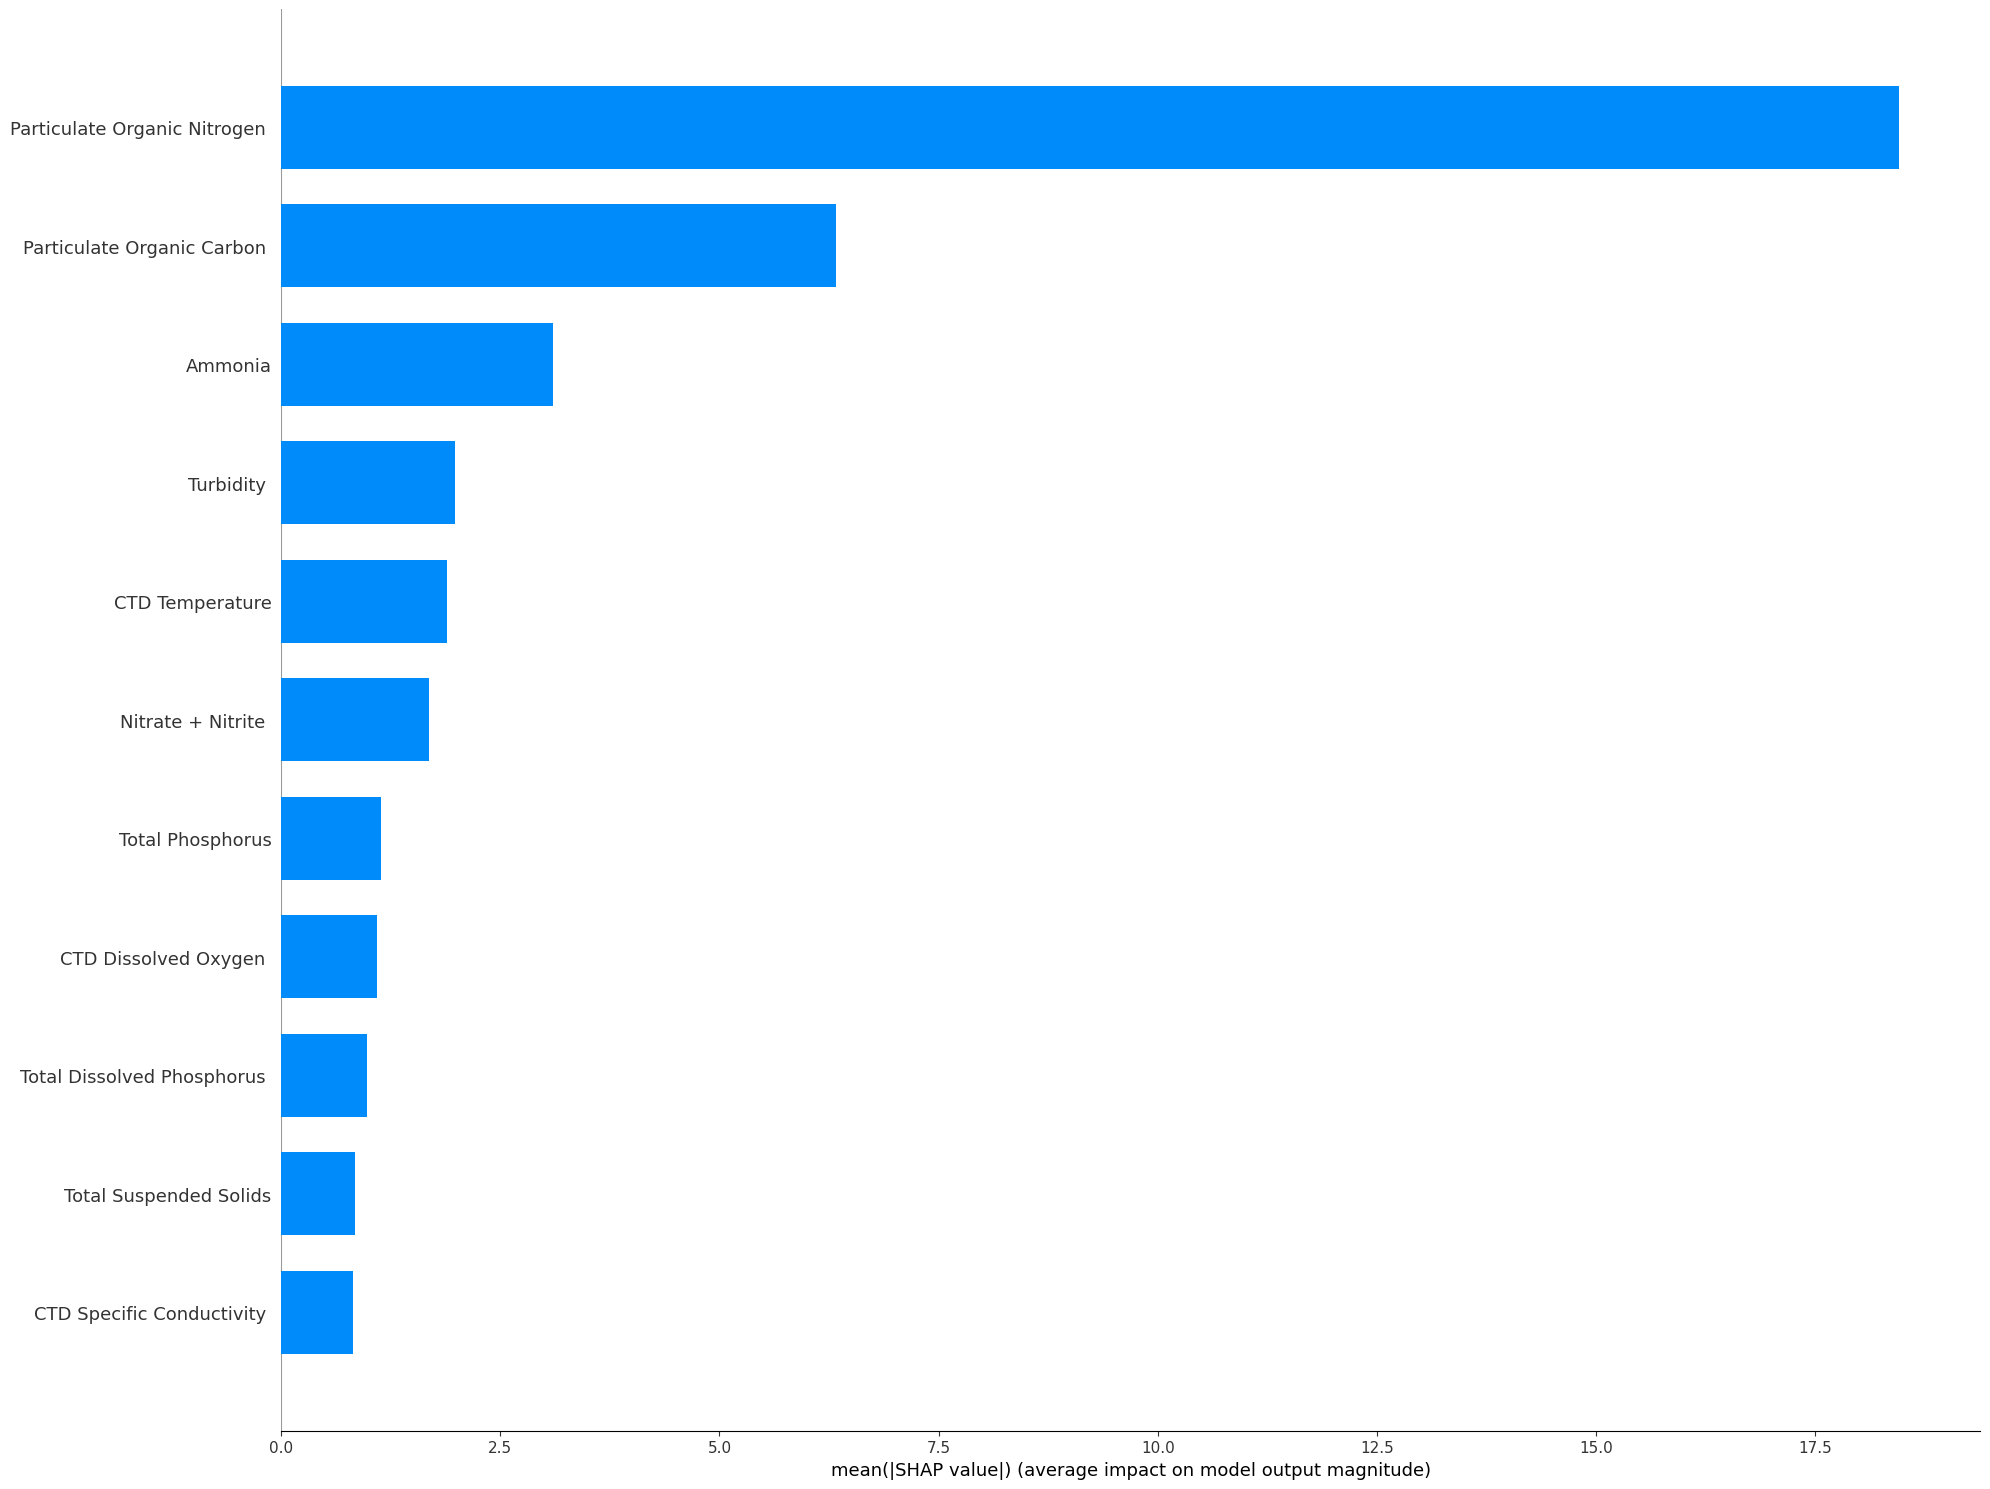

In [19]:
import shap
explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_train)

features = pd.DataFrame(dataset.iloc[:,4:15])
features = features.columns
print(features)

shap.summary_plot(shap_values, X_train,feature_names = features,plot_type="bar",plot_size=(20,15),show=False)


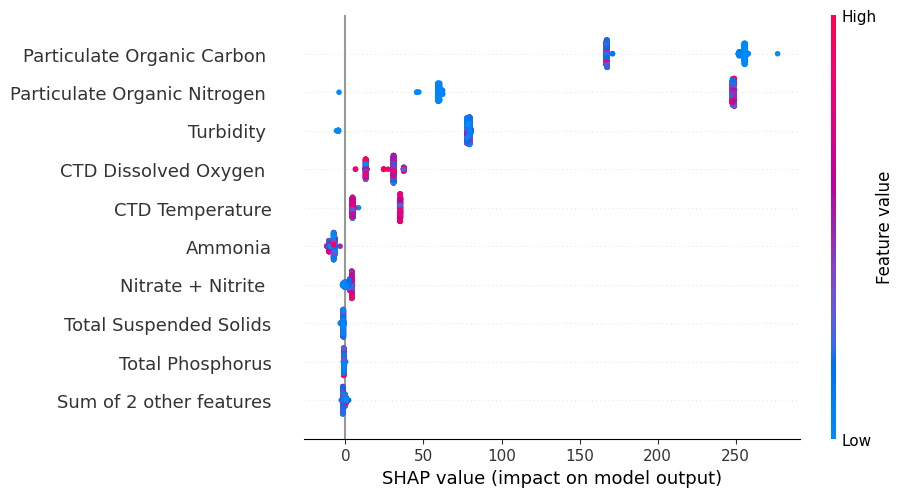

In [20]:
X_test_shap = pd.DataFrame(train.iloc[:,4:15])
shap_values = explainer(X_test_shap)
shap.plots.beeswarm(shap_values=shap_values)

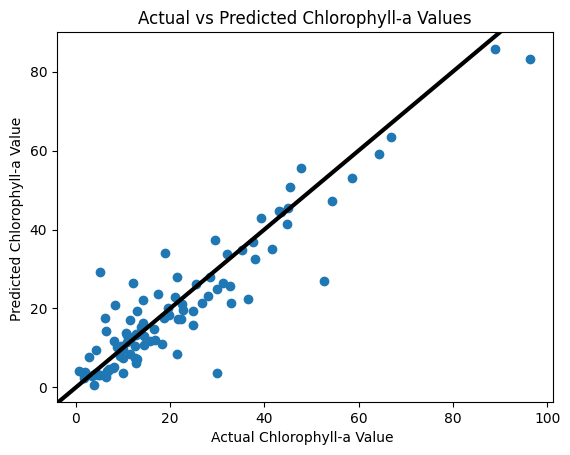

In [21]:
import matplotlib.pyplot as plt
plt.scatter(Y_test, res)
plt.xlabel('Actual Chlorophyll-a Value ')
plt.ylabel('Predicted Chlorophyll-a Value ')
plt.title('Actual vs Predicted Chlorophyll-a Values')
xpoints = ypoints = plt.xlim()
plt.plot(xpoints, ypoints, linestyle='-', color='k', lw=3, scalex=False, scaley=False)
plt.show()